# Week 9 Workshop: Visualization Principles

## Creating Publication-Ready Figures with Budget Execution Data

**Student Name:** Carlos Steven Lozano

**Date:** 9/04/2026

---

### Workshop Objectives

1. Create 5 different chart types with real budget data
2. Apply a consistent, professional color palette
3. Add proper titles, labels, and annotations
4. Export publication-ready figures

---

## Setup

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Create figures directory for exports
os.makedirs('figures', exist_ok=True)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Configure matplotlib for publication quality
plt.style.use('seaborn-v0_8-whitegrid')

# Custom settings
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10

print("Matplotlib configured for publication quality!")

Matplotlib configured for publication quality!


In [3]:
# Load the dataset
# File location: ../data/EJECUCION_PRESUPUESTAL.csv
df = pd.read_csv('../data/EJECUCION_PRESUPUESTAL.csv')

# Display basic information
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

Dataset shape: (3645, 21)

Columns: ['Fuente de Financiación', 'Situación de Fondos', 'Recursos´Presupuestales', 'Codigo Sector', 'Nombre Sector', 'Codigo Entidad', 'Nombre Entidad', 'Código Nivel Uno Rubro', 'Nombre Nivel Uno Rubro', 'Código Nivel Dos Rubro', 'Nombre Niel Dos Rubro', 'Código Nivel Tres Rubro', 'Nombre Nivel Tres Rubro', 'Código Cuarto Nivel Rubro', 'Nombre Cuarto Nivel Rubro', 'Código Quinto Nivel Rubro', 'Nombre Quinto Nivel Rubro', 'Apropiación Vigente', 'Compromisos', 'Obligaciones', 'Pagos']


In [4]:
# Preview the data
df.head()

,Fuente de Financiación,Situación de Fondos,Recursos´Presupuestales,Codigo Sector,Nombre Sector,Codigo Entidad,Nombre Entidad,Código Nivel Uno Rubro,Nombre Nivel Uno Rubro,Código Nivel Dos Rubro,...,Código Nivel Tres Rubro,Nombre Nivel Tres Rubro,Código Cuarto Nivel Rubro,Nombre Cuarto Nivel Rubro,Código Quinto Nivel Rubro,Nombre Quinto Nivel Rubro,Apropiación Vigente,Compromisos,Obligaciones,Pagos
0,Nación,CSF,FONDO ESPECIAL FAZNI,7,MINAS Y ENERGIA,21-01-01,MINISTERIO DE MINAS Y ENERGIA - GESTION GENERAL,C,INVERSION,2102,...,1900,INTERSUBSECTORIAL MINAS Y ENERGÍA,15,AMPLIACION DE LA COBERTURA DEL SERVICIO DE ENE...,40301C,"4. TRANSFORMACIÓN PRODUCTIVA, INTERNACIONALIZA...",230000000000,218423934193,0,0
1,Nación,CSF,FONDO ESPECIAL FAZNI,7,MINAS Y ENERGIA,21-01-01,MINISTERIO DE MINAS Y ENERGIA - GESTION GENERAL,C,INVERSION,2102,...,1900,INTERSUBSECTORIAL MINAS Y ENERGÍA,20,DESARROLLO DE ESTRATEGIAS DE IMPLEMENTACIÓN EN...,40301A,"4. TRANSFORMACIÓN PRODUCTIVA, INTERNACIONALIZA...",300000000000,243608082077,0,0
2,Nación,CSF,FONDOS ESPECIALES,15,INTERIOR,37-01-01,MINISTERIO DEL INTERIOR - GESTION GENERAL,A,FUNCIONAMIENTO,3,...,03,A ENTIDADES DEL GOBIERNO,01,A ÓRGANOS DEL PGN,032,FONDO NACIONAL DE SEGURIDAD Y CONVIVENCIA CIUD...,627264000000,528982310030,0,0
3,Nación,CSF,FONDOS ESPECIALES,15,INTERIOR,37-01-01,MINISTERIO DEL INTERIOR - GESTION GENERAL,C,INVERSION,3702,...,1000,INTERSUBSECTORIAL GOBIERNO,13,FORTALECIMIENTO A LAS ENTIDADES TERRITORIALES ...,20105A,2. SEGURIDAD HUMANA Y JUSTICIA SOCIAL / A. NUE...,81291000000,17203016261,0,0
4,Nación,CSF,FONDOS ESPECIALES,15,INTERIOR,37-01-01,MINISTERIO DEL INTERIOR - GESTION GENERAL,C,INVERSION,3702,...,1000,INTERSUBSECTORIAL GOBIERNO,8,FORTALECIMIENTO DE LOS SISTEMAS INTEGRADOS DE ...,20105A,2. SEGURIDAD HUMANA Y JUSTICIA SOCIAL / A. NUE...,60000000000,49717952500,0,0


In [5]:
# Check data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3645 entries, 0 to 3644
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Fuente de Financiación     3645 non-null   str  
 1   Situación de Fondos        3645 non-null   str  
 2   Recursos´Presupuestales    3645 non-null   str  
 3   Codigo Sector              3645 non-null   int64
 4   Nombre Sector              3645 non-null   str  
 5   Codigo Entidad             3645 non-null   str  
 6   Nombre Entidad             3645 non-null   str  
 7   Código Nivel Uno Rubro     3645 non-null   str  
 8   Nombre Nivel Uno Rubro     3645 non-null   str  
 9   Código Nivel Dos Rubro     3645 non-null   int64
 10  Nombre Niel Dos Rubro      3645 non-null   str  
 11  Código Nivel Tres Rubro    3645 non-null   str  
 12  Nombre Nivel Tres Rubro    3645 non-null   str  
 13  Código Cuarto Nivel Rubro  3645 non-null   str  
 14  Nombre Cuarto Nivel Rubro  3645 non

In [6]:
# Prepare sample data for visualization
# (Use this if the actual dataset columns differ)

np.random.seed(42)

# Budget by category
categories = ['Education', 'Health', 'Infrastructure', 'Security', 'Social Programs', 'Administration']
budget_by_category = pd.DataFrame({
    'Category': categories,
    'Budget_Approved': [450, 380, 290, 220, 160, 100],
    'Budget_Executed': [420, 350, 310, 195, 145, 95]
})
budget_by_category['Execution_Rate'] = (budget_by_category['Budget_Executed'] / 
                                         budget_by_category['Budget_Approved'] * 100).round(1)

# Monthly execution data
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_data = pd.DataFrame({
    'Month': months,
    'Month_Num': range(1, 13),
    'Execution_Rate': [7.8, 15.9, 24.5, 33.2, 41.8, 49.5, 58.2, 66.8, 75.1, 83.5, 91.8, 99.2],
    'Target': [8.3, 16.7, 25.0, 33.3, 41.7, 50.0, 58.3, 66.7, 75.0, 83.3, 91.7, 100.0]
})

# Department execution data
dept_data = pd.DataFrame({
    'Department': ['Finance', 'Human Resources', 'IT', 'Operations', 'Marketing', 'Legal', 'R&D', 'Facilities'],
    'Execution_Pct': [95.2, 88.7, 92.1, 78.4, 85.6, 91.3, 82.5, 89.9],
    'Budget': [120, 85, 150, 200, 95, 60, 180, 70]
})

# Budget composition by type
composition = pd.DataFrame({
    'Year': [2020, 2021, 2022, 2023, 2024],
    'Personnel': [45, 44, 46, 47, 48],
    'Operations': [25, 26, 24, 23, 22],
    'Investment': [20, 19, 21, 22, 23],
    'Debt_Service': [10, 11, 9, 8, 7]
})

print("Sample data prepared!")
print(f"\nDatasets created:")
print(f"  - budget_by_category: {budget_by_category.shape}")
print(f"  - monthly_data: {monthly_data.shape}")
print(f"  - dept_data: {dept_data.shape}")
print(f"  - composition: {composition.shape}")

Sample data prepared!

Datasets created:
  - budget_by_category: (6, 4)
  - monthly_data: (12, 4)
  - dept_data: (8, 3)
  - composition: (5, 5)


---

# Part 1: Data Preparation and Color Palette (15 minutes)

---

## Task 1.1: Explore the Data

In [7]:
# Explore the budget by category data
budget_by_category

,Category,Budget_Approved,Budget_Executed,Execution_Rate
0,Education,450,420,93.3
1,Health,380,350,92.1
2,Infrastructure,290,310,106.9
3,Security,220,195,88.6
4,Social Programs,160,145,90.6
5,Administration,100,95,95.0


In [8]:
# Summary statistics
budget_by_category.describe()

,Budget_Approved,Budget_Executed,Execution_Rate
count,6.000000,6.000000,6.000000
mean,266.666667,252.500000,94.416667
std,132.916014,126.915326,6.499051
min,100.000000,95.000000,88.600000
25%,175.000000,157.500000,90.975000
50%,255.000000,252.500000,92.700000
75%,357.500000,340.000000,94.575000
max,450.000000,420.000000,106.900000


## Task 1.2: Define Your Color Palette

In [9]:
# TODO: Define your professional color palette
# Choose colors that work well together and serve different purposes

# YOUR CODE HERE
COLORS = {
    'primary': 'steelblue',      # Main data color (e.g., '#2C3E50', 'steelblue')
    'secondary': 'lightsteelblue',    # Comparison data (e.g., '#3498DB', 'lightsteelblue')
    'accent': 'lightgreen',       # Highlighting important values (e.g., '#1ABC9C')
    'warning': 'orange',      # Below target / negative (e.g., '#E74C3C', 'coral')
    'neutral': 'gray',      # Reference lines, text (e.g., '#95A5A6', 'gray')
}

# Sequential palette for stacked charts (light to dark)
SEQUENTIAL = ['lightgray', 'lightsteelblue', 'steelblue', 'darkblue']  # e.g., ['#D5E8D4', '#97D077', '#5FAD41', '#2E7D32']

print("Color palette defined!")
print(f"Primary: {COLORS['primary']}")
print(f"Secondary: {COLORS['secondary']}")
print(f"Accent: {COLORS['accent']}")
print(f"Warning: {COLORS['warning']}")
print(f"Neutral: {COLORS['neutral']}")

Color palette defined!
Primary: steelblue
Secondary: lightsteelblue
Accent: lightgreen
Neutral: gray


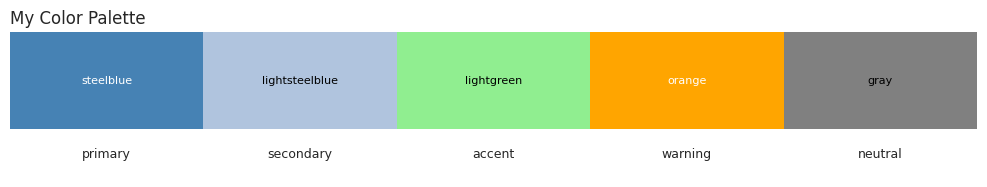

In [10]:
# Visualize your palette
fig, ax = plt.subplots(figsize=(10, 2))

# Show main colors
for i, (name, color) in enumerate(COLORS.items()):
    ax.add_patch(plt.Rectangle((i, 0), 1, 1, facecolor=color))
    ax.text(i + 0.5, -0.2, name, ha='center', va='top', fontsize=9)
    ax.text(i + 0.5, 0.5, color, ha='center', va='center', fontsize=8, 
            color='white' if name in ['primary', 'warning'] else 'black')

ax.set_xlim(0, len(COLORS))
ax.set_ylim(-0.5, 1)
ax.axis('off')
ax.set_title('My Color Palette', fontsize=12, loc='left')
plt.tight_layout()
plt.show()

---

# Part 2: Create 5 Chart Types (75 minutes)

---

## Chart 1: Horizontal Bar Chart - Budget by Category (15 minutes)

Create a clean horizontal bar chart showing budget allocation.

**Requirements:**
- Sort by value (largest at top)
- Use primary color
- Add value labels
- Clean title

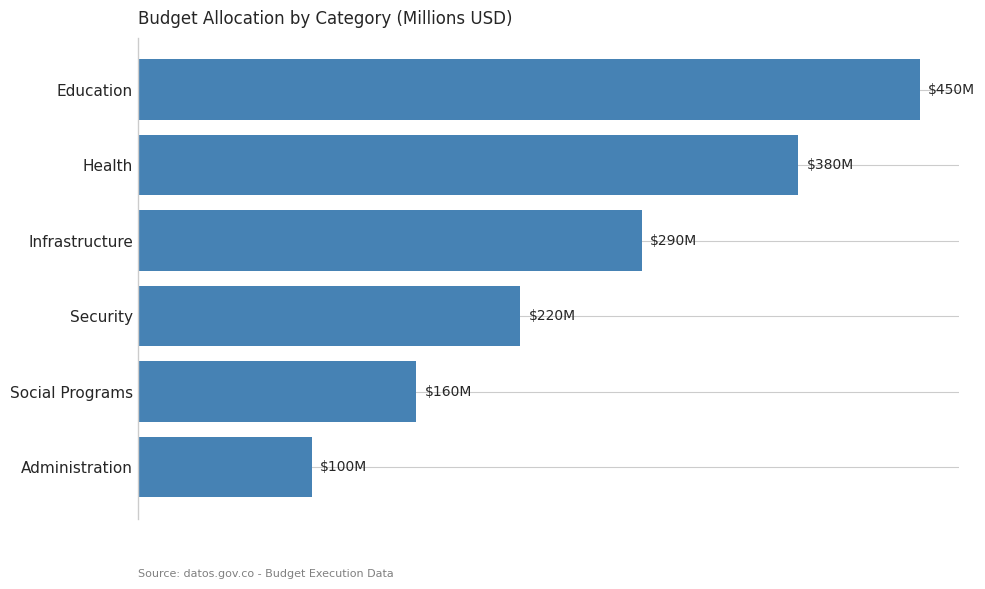

In [11]:
# TODO: Create horizontal bar chart

fig, ax = plt.subplots(figsize=(10, 6))

# Sort data
sorted_data = budget_by_category.sort_values('Budget_Approved', ascending=True)

# YOUR CODE HERE
# Create horizontal bars
bars = ax.barh(
    sorted_data['Category'],  # y: categories
    sorted_data['Budget_Approved'],  # width: budget values
    color=COLORS['primary'],  # Use COLORS['primary']
    edgecolor='none'
)

# Add value labels
for bar, value in zip(bars, sorted_data['Budget_Approved']):
    ax.text(
        bar.get_width() + 5,
        bar.get_y() + bar.get_height()/2,
        f'${value}M',
        va='center',
        fontsize=10
    )

# Remove unnecessary elements
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xticks([])

# Title and labels
ax.set_title('Budget Allocation by Category (Millions USD)', fontsize=12, loc='left', pad=10)

# Add source
ax.text(0, -0.12, 'Source: datos.gov.co - Budget Execution Data', 
        transform=ax.transAxes, fontsize=8, color='gray')

plt.tight_layout()
plt.show()

In [12]:
# TODO: Export Chart 1
# Uncomment and run after your chart looks good

fig.savefig('figures/chart1_budget_by_category.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
fig.savefig('figures/chart1_budget_by_category.svg', format='svg', bbox_inches='tight')
print("Chart 1 exported!")

Chart 1 exported!


## Chart 2: Grouped Bar Chart - Approved vs Executed (15 minutes)

Create a grouped bar chart comparing approved and executed budgets.

**Requirements:**
- Two bars per category (approved and executed)
- Use primary and secondary colors
- Add legend
- Show execution rate

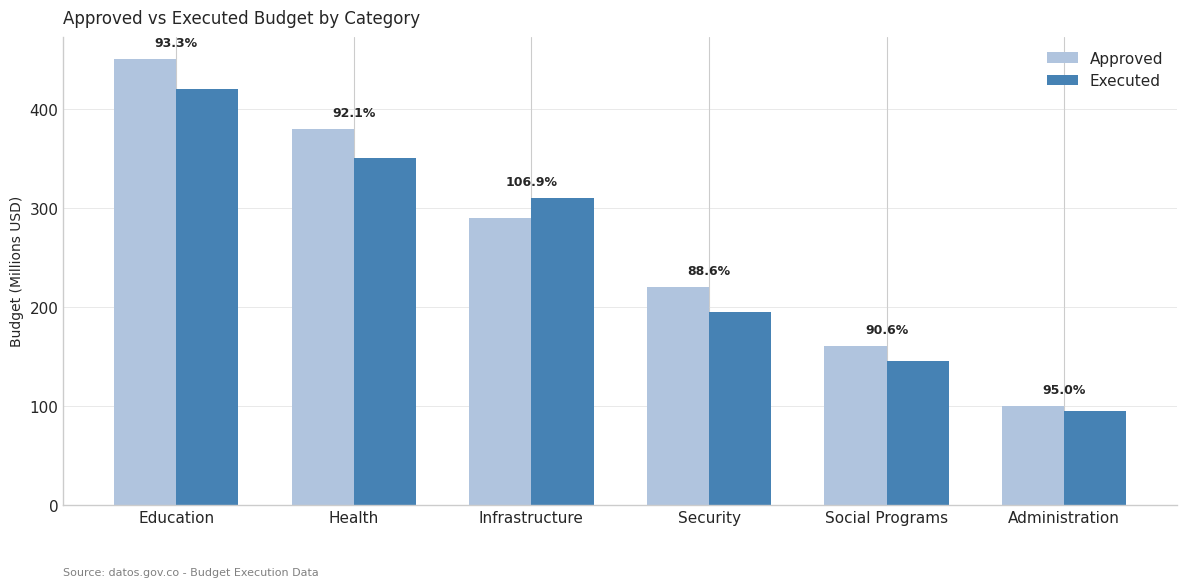

In [13]:
# TODO: Create grouped bar chart

fig, ax = plt.subplots(figsize=(12, 6))

# Set up bar positions
x = np.arange(len(budget_by_category))
width = 0.35

# YOUR CODE HERE
# Create bars for approved budget
bars1 = ax.bar(
    x - width/2,
    budget_by_category['Budget_Approved'],  # Budget_Approved values
    width,
    label='Approved',
    color=COLORS['secondary']  # Use COLORS['secondary']
)

# Create bars for executed budget
bars2 = ax.bar(
    x + width/2,
    budget_by_category['Budget_Executed'],  # Budget_Executed values
    width,
    label='Executed',
    color=COLORS['primary']  # Use COLORS['primary']
)

# Add execution rate labels above each pair
for i, (approved, executed, rate) in enumerate(zip(
    budget_by_category['Budget_Approved'],
    budget_by_category['Budget_Executed'],
    budget_by_category['Execution_Rate']
)):
    ax.text(i, max(approved, executed) + 10, f'{rate}%',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Customize
ax.set_xticks(x)
ax.set_xticklabels(budget_by_category['Category'])
ax.set_ylabel('Budget (Millions USD)')
ax.set_title('Approved vs Executed Budget by Category', fontsize=12, loc='left', pad=10)
ax.legend(frameon=False)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add light horizontal gridlines
ax.yaxis.grid(True, linestyle='-', linewidth=0.5, color='lightgray', alpha=0.7)
ax.set_axisbelow(True)

# Add source
ax.text(0, -0.15, 'Source: datos.gov.co - Budget Execution Data', 
        transform=ax.transAxes, fontsize=8, color='gray')

plt.tight_layout()
plt.show()

In [14]:
# TODO: Export Chart 2
# Uncomment and run after your chart looks good

fig.savefig('figures/chart2_approved_vs_executed.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
fig.savefig('figures/chart2_approved_vs_executed.svg', format='svg', bbox_inches='tight')
print("Chart 2 exported!")

Chart 2 exported!


## Chart 3: Line Chart - Monthly Execution Trend (15 minutes)

Create a line chart showing monthly budget execution vs target.

**Requirements:**
- Two lines: actual and target
- Highlight months below target
- Clean gridlines
- Annotate final value

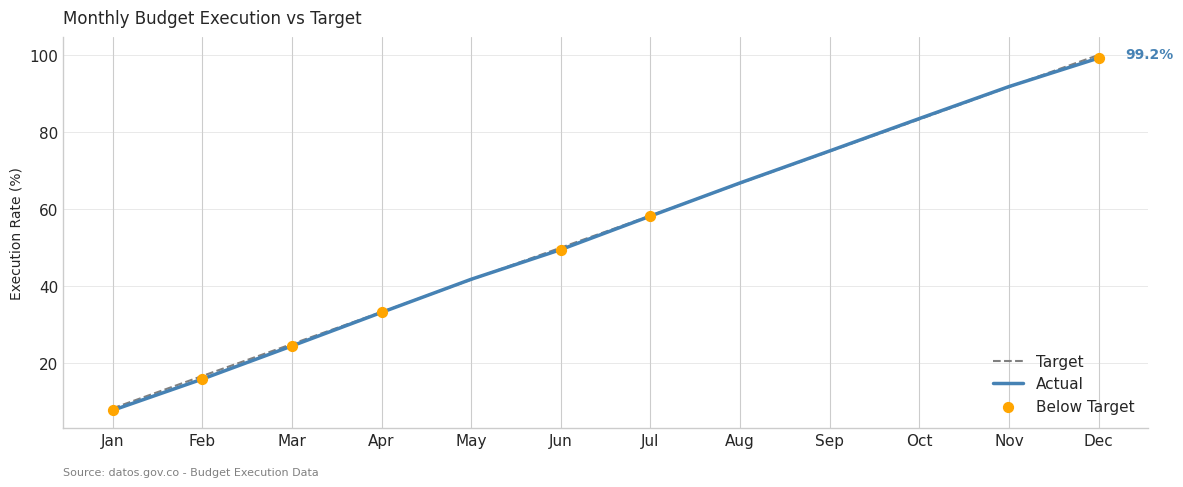

In [15]:
# TODO: Create line chart

fig, ax = plt.subplots(figsize=(12, 5))

# YOUR CODE HERE

# Plot target line (subtle, in background)
ax.plot(
    monthly_data['Month'],
    monthly_data['Target'],
    linestyle='--',
    linewidth=1.5,
    color=COLORS['neutral'],  # Use COLORS['neutral']
    label='Target'
)

# Plot actual execution (prominent)
ax.plot(
    monthly_data['Month'],
    monthly_data['Execution_Rate'],
    linestyle='-',
    linewidth=2.5,
    color=COLORS['primary'],  # Use COLORS['primary']
    label='Actual'
)

# Highlight months below target with markers
below_target = monthly_data[monthly_data['Execution_Rate'] < monthly_data['Target']]
ax.scatter(
    below_target['Month'],
    below_target['Execution_Rate'],
    color=COLORS['warning'],  # Use COLORS['warning']
    s=50,
    zorder=5,
    label='Below Target'
)

# Minimal gridlines (horizontal only)
ax.yaxis.grid(True, linestyle='-', linewidth=0.5, color='lightgray', alpha=0.7)
ax.set_axisbelow(True)

# Labels and title
ax.set_ylabel('Execution Rate (%)')
ax.set_title('Monthly Budget Execution vs Target', fontsize=12, loc='left', pad=10)
ax.legend(frameon=False, loc='lower right')

# Annotate final value
final_rate = monthly_data['Execution_Rate'].iloc[-1]
ax.annotate(
    f'{final_rate}%',
    xy=(11, final_rate),
    xytext=(11.3, final_rate),
    fontsize=10,
    fontweight='bold',
    color=COLORS['primary']
)

# Add source
ax.text(0, -0.12, 'Source: datos.gov.co - Budget Execution Data', 
        transform=ax.transAxes, fontsize=8, color='gray')

plt.tight_layout()
plt.show()

In [16]:
# TODO: Export Chart 3
# Uncomment and run after your chart looks good

fig.savefig('figures/chart3_monthly_execution.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
fig.savefig('figures/chart3_monthly_execution.svg', format='svg', bbox_inches='tight')
print("Chart 3 exported!")

Chart 3 exported!


## Chart 4: Stacked Bar Chart - Budget Composition (15 minutes)

Create a stacked bar chart showing budget composition over years.

**Requirements:**
- Sequential color palette (light to dark)
- Percentage labels within segments
- Legend
- Clean styling

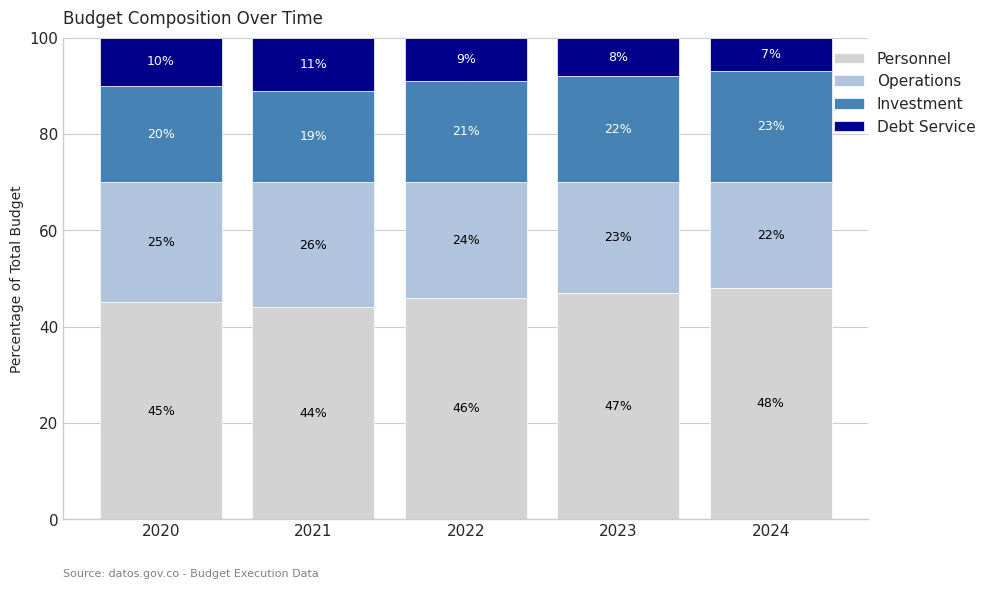

In [17]:
# TODO: Create stacked bar chart

fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data
years = composition['Year']
components = ['Personnel', 'Operations', 'Investment', 'Debt_Service']

# YOUR CODE HERE

# Create stacked bars
bottom = np.zeros(len(years))

for i, component in enumerate(components):
    values = composition[component]
    ax.bar(
        years,
        values,
        bottom=bottom,
        label=component.replace('_', ' '),
        color=SEQUENTIAL[i],  # Use SEQUENTIAL[i]
        edgecolor='white',
        linewidth=0.5
    )
    
    # Add percentage labels in center of each segment
    for j, (year, value) in enumerate(zip(years, values)):
        if value > 5:  # Only label if segment is big enough
            ax.text(
                year,
                bottom[j] + value/2,
                f'{value}%',
                ha='center',
                va='center',
                fontsize=9,
                color='white' if i > 1 else 'black'
            )
    
    bottom += values

# Customize
ax.set_ylabel('Percentage of Total Budget')
ax.set_title('Budget Composition Over Time', fontsize=12, loc='left', pad=10)
ax.legend(frameon=False, loc='upper right', bbox_to_anchor=(1.15, 1))

# Set y-axis limit to 100
ax.set_ylim(0, 100)

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add source
ax.text(0, -0.12, 'Source: datos.gov.co - Budget Execution Data', 
        transform=ax.transAxes, fontsize=8, color='gray')

plt.tight_layout()
plt.show()

In [18]:
# TODO: Export Chart 4
# Uncomment and run after your chart looks good

fig.savefig('figures/chart4_budget_composition.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
fig.savefig('figures/chart4_budget_composition.svg', format='svg', bbox_inches='tight')
print("Chart 4 exported!")

Chart 4 exported!


## Chart 5: Small Multiples - Department Comparison (15 minutes)

Create a small multiples visualization comparing department execution.

**Requirements:**
- Consistent scales across all subplots
- Highlight department below 85% target
- Reference line at 90%
- Minimal styling

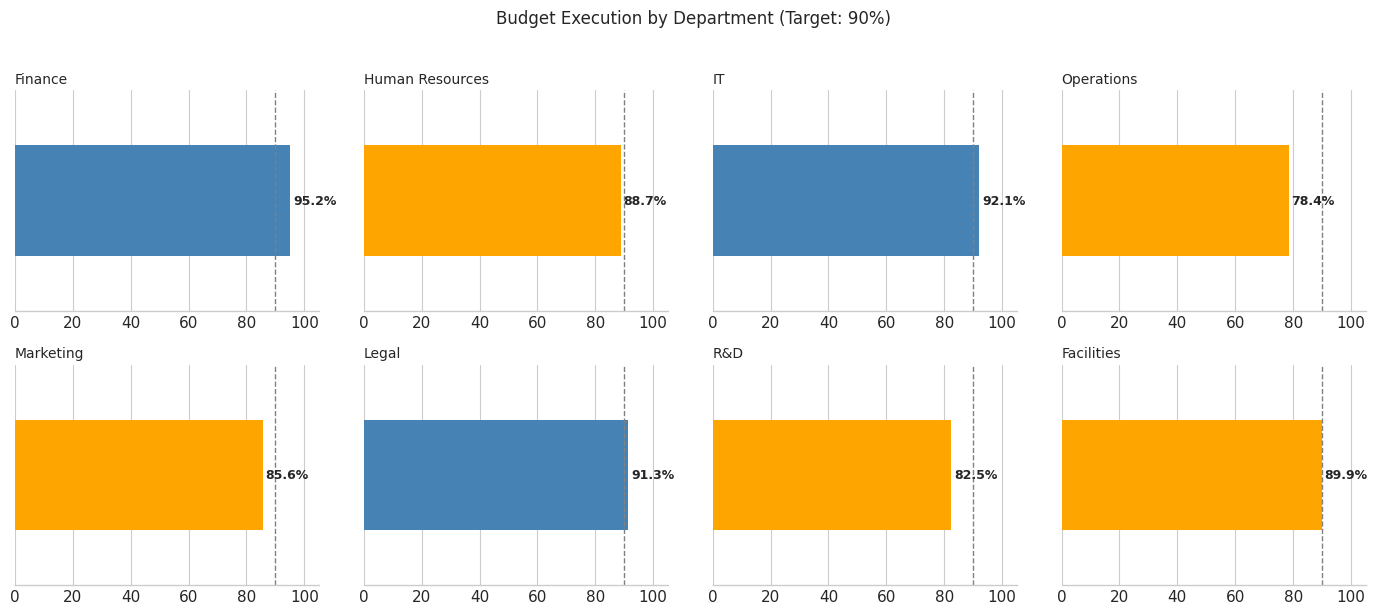

In [19]:
# TODO: Create small multiples

# Calculate grid dimensions
n_depts = len(dept_data)
n_cols = 4
n_rows = (n_depts + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 6))
axes = axes.flatten()

# Target threshold
target = 90

# YOUR CODE HERE

for i, (idx, row) in enumerate(dept_data.iterrows()):
    ax = axes[i]
    
    # Choose color based on whether above/below target
    bar_color = COLORS['primary'] if row['Execution_Pct'] >= target else COLORS['warning']  # primary vs warning
    
    # Create single bar
    ax.barh([0], [row['Execution_Pct']], color=bar_color, height=0.5)
    
    # Add target reference line
    ax.axvline(x=target, color=COLORS['neutral'], linestyle='--', linewidth=1)
    
    # Add value label
    ax.text(row['Execution_Pct'] + 1, 0, f"{row['Execution_Pct']}%",
            va='center', fontsize=9, fontweight='bold')
    
    # Department name as title
    ax.set_title(row['Department'], fontsize=10, loc='left', pad=5)
    
    # Consistent x-axis
    ax.set_xlim(0, 105)
    ax.set_ylim(-0.5, 0.5)
    
    # Remove y-axis and simplify
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Add overall title
fig.suptitle('Budget Execution by Department (Target: 90%)', fontsize=12, y=1.02)

plt.tight_layout()
plt.show()

In [20]:
# TODO: Export Chart 5
# Uncomment and run after your chart looks good

fig.savefig('figures/chart5_department_comparison.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
fig.savefig('figures/chart5_department_comparison.svg', format='svg', bbox_inches='tight')
print("Chart 5 exported!")

Chart 5 exported!


---

# Part 3: Publication-Ready Formatting (20 minutes)

---

## Checklist: Review Your Charts

For each chart, verify:

| Requirement | Chart 1 | Chart 2 | Chart 3 | Chart 4 | Chart 5 |
|-------------|---------|---------|---------|---------|----------|
| Descriptive title | [ ] | [ ] | [ ] | [ ] | [ ] |
| Clear axis labels | [ ] | [ ] | [ ] | [ ] | [ ] |
| Consistent font sizes | [ ] | [ ] | [ ] | [ ] | [ ] |
| Color from palette | [ ] | [ ] | [ ] | [ ] | [ ] |
| Appropriate legend | [ ] | [ ] | [ ] | [ ] | [ ] |
| No unnecessary gridlines | [ ] | [ ] | [ ] | [ ] | [ ] |
| Source attribution | [ ] | [ ] | [ ] | [ ] | [ ] |

In [21]:
# List exported files
import os

if os.path.exists('figures'):
    files = os.listdir('figures')
    print(f"Exported files ({len(files)}):")
    for f in sorted(files):
        size = os.path.getsize(f'figures/{f}') / 1024
        print(f"  - {f} ({size:.1f} KB)")
else:
    print("No figures exported yet.")

Exported files (10):
  - chart1_budget_by_category.png (125.5 KB)
  - chart1_budget_by_category.svg (38.0 KB)
  - chart2_approved_vs_executed.png (152.9 KB)
  - chart2_approved_vs_executed.svg (48.5 KB)
  - chart3_monthly_execution.png (167.5 KB)
  - chart3_monthly_execution.svg (44.0 KB)
  - chart4_budget_composition.png (170.6 KB)
  - chart4_budget_composition.svg (49.3 KB)
  - chart5_department_comparison.png (139.0 KB)
  - chart5_department_comparison.svg (68.6 KB)


---

# Part 4: Critical Analysis (10 minutes)

---

## Critical Analysis Questions

### Question 1: Most Effective Chart Type

Which chart type was most effective for communicating the budget story? Why?

_Your answer:_ The line chart was the most effective because it clearly shows how the budget execution changes over time and makes it easy to compare with the target.

---

### Question 2: Insight from Multiple Charts

What insight would be missed if you only used one chart type?

_Your answer:_ Using multiple charts helps to see different perspectives, like distribution, comparison, and trends. With only one chart, some important details would be missing.

---

### Question 3: One Chart for Decision-Maker

If you could only show one chart to a decision-maker, which would you choose and why?

_Your answer:_ I would choose the grouped bar chart because it clearly compares approved vs executed budget, which helps make quick decisions.

---

### Question 4: Additional Data

What additional data would make these visualizations more impactful?

_Your answer:_ It would be useful to add data like previous years, total budget, or reasons for low execution to better understand the results.

---

## Color Palette Documentation

Document your color choices:

| Purpose | Hex Code | Rationale |
|---------|----------|----------|
| Primary | #2C3E50 | Main data color, professional and easy to read |
| Secondary |  #3498DB| Used for comparison, lighter but consistent with primary |
| Accent | #1ABC9C | Highlights important values without being too aggressive |
| Warning | #E74C3C | Draws attention to underperformance or critical values |
| Neutral | #95A5A6 | Used for reference elements like gridlines and labels |

---

## Summary

### Key Takeaways

1. **Data-Ink Ratio:** Remove unnecessary elements to let data speak

2. **Chart Selection:** Choose the right chart for the data and message

3. **Color Usage:** Use color purposefully, not decoratively

4. **Consistency:** Apply the same styling across all charts

5. **Export Quality:** High DPI for print, vector for presentations

---

## Submission Checklist

- [ ] All 5 charts created and styled
- [ ] Color palette defined and documented
- [ ] 10 files exported (5 PNG + 5 SVG)
- [ ] Critical analysis questions answered
- [ ] Source attribution on all charts

---

*End of Workshop*